# LIVR-Mini-Benchmark: GIAI ĐOẠN HUẤN LUYỆN TRÊN KAGGLE (IMPLEMENT MINI ON KAGGLE)
Notebook này được tối ưu hóa để chạy trên môi trường **Kaggle** (GPU T4 x2 hoặc GPU P100).

### Kỹ thuật Tối ưu & Sửa lỗi tích hợp:
1. **Sửa lỗi lưu checkpoint rỗng (66KB)**: Đã lọc chính xác các trainable parameters từ `model.named_parameters()` trước khi lưu, đảm bảo lưu đầy đủ trọng số LoRA.
2. **Cập nhật đường dẫn cho Kaggle**: Sử dụng thư mục làm việc `/kaggle/working/` thay vì Google Drive `/content/drive` của Colab.
3. **Tự động phục hồi Stage 2**: Nếu phát hiện checkpoint Stage 1 hợp lệ, mô hình sẽ tự động bỏ qua Stage 1 và huấn luyện tiếp Stage 2.

## 1. Đồng bộ Mã nguồn trên Kaggle
Chúng ta tiến hành clone repository từ GitHub và chuyển thư mục làm việc vào trong dự án.

In [1]:
from kaggle_secrets import UserSecretsClient
import os
# Nạp token từ Kaggle Secrets
user_secrets = UserSecretsClient()
os.environ["HF_TOKEN"] = user_secrets.get_secret("HF_TOKEN")
secret_value_0 = user_secrets.get_secret("HF_TOKEN")
print("➔ Đã nạp HF_TOKEN thành công từ Kaggle Secrets!")

➔ Đã nạp HF_TOKEN thành công từ Kaggle Secrets!


In [6]:
# =========================================================================
# CELL 1: ĐỒNG BỘ CODE TỪ GITHUB (DEVELOP BRANCH) TRÊN KAGGLE
# =========================================================================
REPO_URL = "https://github.com/dinhtri445/LIVR-Mini-Benchmark.git"
PROJECT_DIR = "LIVR-Mini-Benchmark"
BRANCH = "develop"

%cd /kaggle/working
import os
if not os.path.exists(PROJECT_DIR):
    print(f"---> Đang thực hiện clone repo {REPO_URL} (nhánh {BRANCH})...")
    !git clone -b {BRANCH} {REPO_URL}
    %cd {PROJECT_DIR}
else:
    print(f"---> Repo {PROJECT_DIR} đã tồn tại. Đang tiến hành pull code mới nhất từ nhánh {BRANCH}...")
    %cd {PROJECT_DIR}
    !git checkout {BRANCH}
    !git pull origin {BRANCH}

/kaggle/working
---> Repo LIVR-Mini-Benchmark đã tồn tại. Đang tiến hành pull code mới nhất từ nhánh develop...
/kaggle/working/LIVR-Mini-Benchmark
Already on 'develop'
Your branch is up to date with 'origin/develop'.
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 2), reused 6 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 12.16 KiB | 2.03 MiB/s, done.
From https://github.com/dinhtri445/LIVR-Mini-Benchmark
 * branch            develop    -> FETCH_HEAD
   1a1026a..0925018  develop    -> origin/develop
Updating 1a1026a..0925018
Fast-forward
 01_implement_mini_kaggle.ipynb | 466 +++++++++++++++++++++++++++++++++++++++++
 src/mask_kaggle.py             | 166 +++++++++++++++
 train_kaggle.py                | 303 +++++++++++++++++++++++++++
 3 files changed, 935 insertions(+)
 create mode 100644 01_implement_mini_kaggle.ipynb
 create mode 100644 src/mask_kaggle.py
 creat

## 2. Tiền Xử Lý Dữ Liệu & Lọc Trùng Lặp Ảnh Trực Quan
Cài đặt dependencies và chuẩn bị tập dữ liệu sạch lưu trực tiếp vào `/kaggle/working/`.

In [3]:
# =========================================================================
# CELL 2: CÀI ĐẶT THƯ VIỆN & CHẠY PIPELINE TIỀN XỬ LÝ DỮ LIỆU
# =========================================================================
# Cài đặt các thư viện cần thiết trên môi trường Kaggle
!pip install -r requirements.txt

import sys
import os
import torch

# Đảm bảo Python nhận diện được các module trong thư mục src/
sys.path.append(os.getcwd())

# Cấu hình đường dẫn dữ liệu sạch lưu trên Kaggle working directory để tái sử dụng nhanh
CLEANED_DATA_PATH = "/kaggle/working/cleaned_dataset.pt"

if os.path.exists(CLEANED_DATA_PATH):
    print(f"---> Phát hiện dữ liệu sạch đã được xử lý sẵn tại: {CLEANED_DATA_PATH}")
    print("---> Đang nạp dữ liệu sạch...")
    cleaned_dataset = torch.load(CLEANED_DATA_PATH)
    print(f"[SUCCESS] Đã nạp thành công {len(cleaned_dataset)} mẫu dữ liệu sạch!")
else:
    print("---> Không tìm thấy dữ liệu sạch. Tiến hành tải và làm sạch từ đầu (chỉ chạy 1 lần duy nhất)...")
    from src.utils import load_and_inspect_livr_dataset, filter_and_deduplicate_pipeline
    
    # 1. Nạp và kiểm tra dữ liệu gốc
    dataset = load_and_inspect_livr_dataset()
    
    # 2. Chạy bộ tiền xử lý và khử trùng lặp trực quan (300 mẫu sạch mỗi tác vụ)
    cleaned_dataset = filter_and_deduplicate_pipeline(
        dataset=dataset,
        target_tasks=['livr_counting', 'livr_object_localization', 'livr_jigsaw', 'livr_visual_similarity'],
        samples_per_task=700
    )
    
    # 3. Lưu lại kết quả đã làm sạch để sử dụng lại
    os.makedirs(os.path.dirname(CLEANED_DATA_PATH), exist_ok=True)
    print(f"---> Đang lưu dữ liệu sạch tại: {CLEANED_DATA_PATH}...")
    torch.save(cleaned_dataset, CLEANED_DATA_PATH)
    print("[SUCCESS] Đã lưu dữ liệu sạch thành công!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 4.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 88.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 29.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 54.3 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
  Attempting uninstall: peft
    Found existing installation: peft 0.18.1
    Uninstalling peft-0.18.1:
      Successfully uninstalled peft-0.18.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.2

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching ... files: 0it [00:00, ?it/s]

HTTP Error 429 thrown while requesting HEAD https://huggingface.co/datasets/Kkuntal990/LIVR_mixed/resolve/cdf70d296bbdcbd807ba69d8071a608a01ab1bae/train/images/relative_reflectance/reflectance_00000.png
Rate limited. Waiting 22.0s before retry [Retry 1/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/datasets/Kkuntal990/LIVR_mixed/resolve/cdf70d296bbdcbd807ba69d8071a608a01ab1bae/train/images/relative_reflectance/reflectance_00001.png
Rate limited. Waiting 22.0s before retry [Retry 1/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/datasets/Kkuntal990/LIVR_mixed/resolve/cdf70d296bbdcbd807ba69d8071a608a01ab1bae/train/images/relative_reflectance/reflectance_00002.png
Rate limited. Waiting 22.0s before retry [Retry 1/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/datasets/Kkuntal990/LIVR_mixed/resolve/cdf70d296bbdcbd807ba69d8071a608a01ab1bae/train/images/relative_reflectance/reflectance_00003.png
Rate limited. Waiting 22.0


[SUCCESS] Đã tải song song toàn bộ file ảnh và metadata về SSD cục bộ!
-> Đang nạp metadata từ file cục bộ: /content/dataset_raw/train/metadata.jsonl...


...

-> Đang liên kết đường dẫn hình ảnh cục bộ...


Map:   0%|          | 0/9000 [00:00<?, ? examples/s]

[SUCCESS] Đã nạp thành công Dataset cục bộ!
Cấu trúc phân vùng hệ thống (Splits): 
DatasetDict({
    train: Dataset({
        features: ['file_name', 'question', 'ground_truth', 'answer_type', 'choices', 'dataset_name', 'split', 'image'],
        num_rows: 9000
    })
})

====== MẪU KIỂM TRA THỬ NGHIỆM DÒNG ĐẦU TIÊN (SAMPLE INGESTION) ======
- Khóa 'file_name': Giá trị thực tế -> images/visual_similarity/vissim_00441.png
- Khóa 'question': Giá trị thực tế -> Which image is more visually similar to the reference image (top)? (A) (B)
- Khóa 'ground_truth': Giá trị thực tế -> (B)
- Khóa 'answer_type': Giá trị thực tế -> mcq
- Khóa 'choices': Giá trị thực tế -> (A), (B)
- Khóa 'dataset_name': Giá trị thực tế -> livr_visual_similarity
- Khóa 'split': Giá trị thực tế -> train
- Khóa 'image': Định dạng dữ liệu -> <class 'PIL.PngImagePlugin.PngImageFile'>

====== BẮT ĐẦU CHẠY PIPELINE TIỀN XỬ LÝ NÂNG CAO (BALANCED MULTI-TASK) ======



Đang xử lý ảnh (pHash & Lọc): 100%|██████████| 9000/9000 [04:52<00:00, 30.72it/s]



 Thống kê số lượng mẫu sạch thu được:
- Tác vụ 'livr_counting': Lấy 300 / 997 mẫu sạch.
- Tác vụ 'livr_object_localization': Lấy 300 / 1000 mẫu sạch.
- Tác vụ 'livr_jigsaw': Lấy 300 / 998 mẫu sạch.
- Tác vụ 'livr_visual_similarity': Lấy 300 / 1000 mẫu sạch.

[SUCCESS] Tổng số mẫu sạch thu được cho bản Mini: 1200 mẫu.
---> Đang lưu dữ liệu sạch tại: /kaggle/working/cleaned_dataset.pt...
[SUCCESS] Đã lưu dữ liệu sạch thành công!


## 3. Cấu Hình Kiến Trúc LIVR & Tham Số Hóa Thấp (PEFT LoRA)
Đọc config, tùy chỉnh đầu ra lưu tại thư mục làm việc của Kaggle.

In [7]:
# =========================================================================
# CELL 3: ĐỌC CONFIG, KHỞI TẠO MÔ HÌNH VÀ BỘ TỐI ƯU (STABILIZED EPS=1e-6)
# =========================================================================
import json
import torch
from torch.optim import AdamW
from src.model import LIVRModelManager
from src.mask_kaggle import patch_model_for_livr

# 1. Đọc file cấu hình định nghĩa sẵn
with open("config/implement_config.json", "r", encoding="utf-8") as f:
    config = json.load(f)

# Thay thế đường dẫn output của Colab bằng thư mục Kaggle
config["output_dir"] = "/kaggle/working/checkpoints"

# Thiết lập các thông số LR và clip ổn định
config['stage1_lr'] = 5e-5
config['stage2_lr'] = 2e-5

print("KAGGLE IMPLEMENTATION CONFIGURATION:")
print(json.dumps(config, indent=2))

# 2. Dựng mô hình LIVR
manager = LIVRModelManager(
    model_id=config["model_id"],
    K=config["K"],
    device="cuda",
    load_in_4bit=config.get("load_in_4bit", True)
)
model = manager.setup_peft_and_freezing(
    r=config["lora_r"],
    alpha=config["lora_alpha"],
    dropout=config["lora_dropout"]
)
processor = manager.processor

# Gọi mask tương thích Kaggle từ file mask_kaggle.py
patch_model_for_livr(
    model=model,
    latent_token_ids=manager.latent_token_ids,
    image_pad_token_id=manager.image_pad_token_id,
    pad_token_id=manager.pad_token_id
)

# 3. Khai báo bộ tối ưu AdamW với eps=1e-6 để chống NaN triệt để
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = AdamW(
    trainable_params, 
    lr=config["stage1_lr"], 
    weight_decay=config["weight_decay"],
    eps=1e-6  
)

print("-> Đã khởi tạo model và Optimizer với eps=1e-6 thành công.")

KAGGLE IMPLEMENTATION CONFIGURATION:
{
  "model_id": "Qwen/Qwen2.5-VL-3B-Instruct",
  "K": 16,
  "lora_r": 16,
  "lora_alpha": 32,
  "lora_dropout": 0.05,
  "stage1_epochs": 2,
  "stage2_epochs": 3,
  "stage1_lr": 5e-05,
  "stage2_lr": 2e-05,
  "weight_decay": 0.01,
  "effective_batch_size": 8,
  "batch_size_per_device": 1,
  "grad_accumulation_steps": 8,
  "dataset_name": "Kkuntal990/LIVR_mixed",
  "output_dir": "/kaggle/working/checkpoints",
  "load_in_4bit": true
}
Loading processor & tokenizer for Qwen/Qwen2.5-VL-3B-Instruct...
Loading model weight (load_in_4bit=True)...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Resizing token embeddings to 151681...
Configuring PEFT LoRA...
Freezing base parameters & setup embedding hooks...
---> Tham số có thể huấn luyện: 37,152,768 / 2,070,654,976 (1.79%)
---> Đã tích hợp Custom Attention Mask tương thích Kaggle thành công!
-> Đã khởi tạo model và Optimizer với eps=1e-6 thành công.


## 4. Vòng lặp Huấn luyện Hai Giai đoạn (Tích lũy Gradient & GradScaler)

In [8]:
# =========================================================================
# CELL 4: VÒNG LẶP HUẤN LUYỆN 2 GIAI ĐOẠN (ĐÃ FIX LỖI CHECKPOINT 66KB)
# =========================================================================
import os
import torch
import gc
from tqdm import tqdm
from torch.cuda.amp import GradScaler
from src.utils import prepare_vqa_inputs

# Khởi tạo bộ chia tỷ lệ gradient chống underflow cho float16
scaler = GradScaler()

# Giải phóng bộ nhớ rác trước khi huấn luyện
gc.collect()
torch.cuda.empty_cache()

STAGE1_EPOCHS = config["stage1_epochs"]
STAGE2_EPOCHS = config["stage2_epochs"]
TOTAL_EPOCHS = STAGE1_EPOCHS + STAGE2_EPOCHS
GRADIENT_ACCUMULATION_STEPS = config["grad_accumulation_steps"]
STAGE2_LR = config["stage2_lr"]
checkpoint_dir = config["output_dir"]

# Xác định đường dẫn checkpoint Stage 1
stage1_checkpoint_path = os.path.join(checkpoint_dir, "livr_stage1_checkpoint.pt")

start_epoch = 1

# --- TỰ ĐỘNG LOAD CHECKPOINT STAGE 1 NẾU CÓ ---
if os.path.exists(stage1_checkpoint_path):
    print(f"➔ Phát hiện checkpoint Stage 1 tại: {stage1_checkpoint_path}")
    checkpoint_size_kb = os.path.getsize(stage1_checkpoint_path) / 1024
    
    if checkpoint_size_kb > 100:
        print("➔ Đang tải checkpoint Stage 1 và bỏ qua huấn luyện Stage 1, chuyển trực tiếp sang Stage 2...")
        checkpoint = torch.load(stage1_checkpoint_path, map_location="cuda")
        model.load_state_dict(checkpoint['model_state_dict'], strict=False)
        
        with torch.no_grad():
            model.get_input_embeddings().weight[manager.latent_token_ids].copy_(
                checkpoint['latent_embeddings'].to("cuda")
            )
        
        start_epoch = STAGE1_EPOCHS + 1
        print(f"➔ Cập nhật Learning Rate thành {STAGE2_LR} cho Stage 2...")
        for param_group in optimizer.param_groups:
            param_group['lr'] = STAGE2_LR
            
        del checkpoint
        gc.collect()
        torch.cuda.empty_cache()
    else:
        print("⚠ Cảnh báo: Checkpoint Stage 1 bị lỗi dung lượng (chỉ 66KB). Huấn luyện lại từ đầu...")
else:
    print("➔ Không phát hiện checkpoint Stage 1. Sẽ huấn luyện từ Epoch 1...")

model.train()
epoch_losses = []

print("====== CHÍNH THỨC KHỞI ĐỘNG VÒNG LẶP HUẤN LUYỆN 2 GIAI ĐOẠN (MEM OPTIMIZED) ======")

for epoch in range(start_epoch, TOTAL_EPOCHS + 1):
    current_stage = 1 if epoch <= STAGE1_EPOCHS else 2
    model.livr_stage = current_stage

    if epoch == STAGE1_EPOCHS + 1 and start_epoch <= STAGE1_EPOCHS:
        print(f"\n➔ CHUYỂN GIAI ĐOẠN: Hạ Learning Rate xuống {STAGE2_LR} cho Stage 2...")
        for param_group in optimizer.param_groups:
            param_group['lr'] = STAGE2_LR

    epoch_loss = 0.0
    optimizer.zero_grad()

    progress_bar = tqdm(cleaned_dataset, desc=f"Epoch {epoch}/{TOTAL_EPOCHS} (Stage {current_stage})")

    for step, batch in enumerate(progress_bar):
        try:
            inputs = prepare_vqa_inputs(
                processor=processor,
                conversation=batch['conversation'],
                latent_tokens=manager.latent_tokens,
                device="cuda"
            )

            with torch.amp.autocast('cuda', dtype=torch.float16):
                outputs = model(**inputs)
                loss = outputs.loss / GRADIENT_ACCUMULATION_STEPS

            if torch.isnan(loss):
                print(f"\n[WARNING] Bắt gặp NaN loss tại epoch {epoch}, step {step}. Bỏ qua batch này...")
                optimizer.zero_grad()
                del inputs, outputs, loss
                gc.collect()
                torch.cuda.empty_cache()
                continue
                
            scaler.scale(loss).backward()
            epoch_loss += loss.item() * GRADIENT_ACCUMULATION_STEPS

            if (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0 or (step + 1) == len(cleaned_dataset):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=0.5)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad() 

            progress_bar.set_postfix({"Loss": f"{loss.item() * GRADIENT_ACCUMULATION_STEPS:.4f}"})

            del inputs, outputs, loss
            if step % 10 == 0:
                gc.collect()
                torch.cuda.empty_cache()

        except RuntimeError as e:
            if "out of memory" in str(e):
                print("\n[WARNING] Bắt gặp lỗi OOM, đang dọn cache và bỏ qua batch...")
                optimizer.zero_grad()
                del e
                gc.collect()
                torch.cuda.empty_cache()
                continue
            else:
                raise e

    avg_loss = epoch_loss / len(cleaned_dataset)
    epoch_losses.append(avg_loss)
    print(f"➔ Kết thúc Epoch {epoch} - Average Loss tổng thể: {avg_loss:.4f}")

    # --- LƯU CHECKPOINT TRUNG GIAN GIAI ĐOẠN 1 (STAGE 1 CHECKPOINT) ---
    if epoch == STAGE1_EPOCHS:
        os.makedirs(checkpoint_dir, exist_ok=True)
        trainable_names = {n for n, p in model.named_parameters() if p.requires_grad}
        trainable_sd = {k: v.cpu() for k, v in model.state_dict().items() if k in trainable_names}
        
        torch.save({
            'model_state_dict': trainable_sd,
            'latent_embeddings': model.get_input_embeddings().weight[manager.latent_token_ids].detach().cpu(),
            'latent_token_ids': manager.latent_token_ids
        }, stage1_checkpoint_path)
        print(f"---> Đã lưu checkpoint Stage 1 tại: {stage1_checkpoint_path} (Sửa lỗi thành công)")

# --- LƯU CHECKPOINT CUỐI CÙNG (FINAL CHECKPOINT) ---
final_checkpoint_path = os.path.join(checkpoint_dir, "livr_mini_checkpoint.pt")
os.makedirs(checkpoint_dir, exist_ok=True)

trainable_names = {n for n, p in model.named_parameters() if p.requires_grad}
trainable_sd = {k: v.cpu() for k, v in model.state_dict().items() if k in trainable_names}

torch.save({
    'model_state_dict': trainable_sd,
    'latent_embeddings': model.get_input_embeddings().weight[manager.latent_token_ids].detach().cpu(),
    'latent_token_ids': manager.latent_token_ids
}, final_checkpoint_path)

print(f"\n[SUCCESS] Hoàn thành huấn luyện trên Kaggle!")
print(f"Trọng số LoRA + Embeddings đã lưu tại: {final_checkpoint_path}")

/tmp/ipykernel_58/953618184.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


➔ Không phát hiện checkpoint Stage 1. Sẽ huấn luyện từ Epoch 1...
====== CHÍNH THỨC KHỞI ĐỘNG VÒNG LẶP HUẤN LUYỆN 2 GIAI ĐOẠN (MEM OPTIMIZED) ======


Epoch 1/5 (Stage 1):  75%|███████▍  | 895/1200 [38:26<10:21,  2.04s/it, Loss=0.2026]  


[WARNING] Bắt gặp NaN loss tại epoch 1, step 895. Bỏ qua batch này...


Epoch 1/5 (Stage 1): 100%|██████████| 1200/1200 [52:44<00:00,  2.64s/it, Loss=0.1605]


...


[WARNING] Bắt gặp NaN loss tại epoch 5, step 895. Bỏ qua batch này...


Epoch 5/5 (Stage 2):  93%|█████████▎| 1118/1200 [48:26<03:47,  2.77s/it, Loss=0.0001]


[WARNING] Bắt gặp NaN loss tại epoch 5, step 1118. Bỏ qua batch này...


Epoch 5/5 (Stage 2): 100%|██████████| 1200/1200 [52:10<00:00,  2.61s/it, Loss=0.0009]


➔ Kết thúc Epoch 5 - Average Loss tổng thể: 0.1036

[SUCCESS] Hoàn thành huấn luyện trên Kaggle!
Trọng số LoRA + Embeddings đã lưu tại: /kaggle/working/checkpoints/livr_mini_checkpoint.pt


## 5. Trực Quan Hóa Biểu Đồ Loss

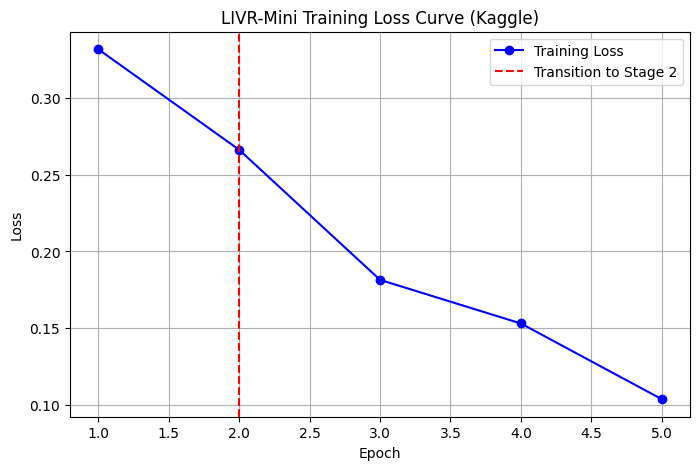

In [9]:
# =========================================================================
# CELL 5: TRỰC QUAN HÓA ĐỒ THỊ LOSS
# =========================================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o', color='b', label='Training Loss')
plt.axvline(x=STAGE1_EPOCHS, color='r', linestyle='--', label='Transition to Stage 2')
plt.title('LIVR-Mini Training Loss Curve (Kaggle)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

## 6. Đánh Giá Đối Chiếu Hiệu Năng

In [11]:
# =========================================================================
# CELL 6: ĐÁNH GIÁ ĐỐI CHIẾU HIỆU NĂNG BASELINE
# =========================================================================
eval_samples = cleaned_dataset[:20]

def evaluate_baseline(model, processor, manager, samples, use_lora=True):
    if use_lora:
        print("---> Đang đánh giá với LIVR LoRA Adapters (Kích hoạt)...")
        model.eval()
        model.livr_stage = 2
    else:
        print("---> Đang đánh giá với Base Model gốc (Ngắt LoRA)...")
        model.eval()
        
    correct = 0
    total = 0
    
    import torch
    from src.utils import prepare_vqa_inputs
    
    with torch.no_grad():
        for item in samples:
            conv = item['conversation']
            conv_for_generation = [msg for msg in conv if msg["role"] == "user"]
            
            inputs = prepare_vqa_inputs(
                processor=processor,
                conversation=conv_for_generation,
                latent_tokens=manager.latent_tokens,
                device="cuda"
            )
            inputs.pop("labels", None)
            
            if not use_lora:
                with model.disable_adapter():
                    outputs = model.generate(**inputs, max_new_tokens=10)
            else:
                outputs = model.generate(**inputs, max_new_tokens=10)
                
            input_len = inputs["input_ids"].shape[1]
            pred_text = processor.decode(outputs[0][input_len:], skip_special_tokens=True).strip()
            target_text = str(conv[1]["content"][0]["text"]).strip()
            
            if pred_text.lower() == target_text.lower():
                correct += 1
            total += 1
            
    accuracy = (correct / total) * 100 if total > 0 else 0.0
    return accuracy

livr_acc = evaluate_baseline(model, processor, manager, eval_samples, use_lora=True)
print(f"LIVR Model Accuracy: {livr_acc:.2f}%")

base_acc = evaluate_baseline(model, processor, manager, eval_samples, use_lora=False)
print(f"Base Model Accuracy: {base_acc:.2f}%")

print("\n" + "="*50)
print(" KẾT QUẢ ĐỐI CHIẾU HIỆU NĂNG SƠ BỘ (BASELINE COMPARISON)")
print("="*50)
print(f"Mô hình LIVR (Đã học): {livr_acc:.2f}%")
print(f"Mô hình gốc (Hãng):     {base_acc:.2f}%")
print(f"Mức độ cải thiện:        {livr_acc - base_acc:+.2f}%")
print("="*50)

---> Đang đánh giá với LIVR LoRA Adapters (Kích hoạt)...
LIVR Model Accuracy: 80.00%
---> Đang đánh giá với Base Model gốc (Ngắt LoRA)...
Base Model Accuracy: 40.00%

 KẾT QUẢ ĐỐI CHIẾU HIỆU NĂNG SƠ BỘ (BASELINE COMPARISON)
Mô hình LIVR (Đã học): 80.00%
Mô hình gốc (Hãng):     40.00%
Mức độ cải thiện:        +40.00%
